Using device: cpu
Created directories: artifacts/figures
Dataset found at: /Users/reginasadykova/Desktop/ai-course2-regina-2025/homeworks/HW12/S12-hw-dataset.csv

Number of observations: 4320
Date range: from 2025-01-01 00:00:00 to 2025-06-29 23:00:00

Missing values:
date      0
target    0
dtype: int64

First 5 rows:
                 date  target
0 2025-01-01 00:00:00   98.14
1 2025-01-01 01:00:00   98.07
2 2025-01-01 02:00:00  104.70
3 2025-01-01 03:00:00  112.81
4 2025-01-01 04:00:00  112.62


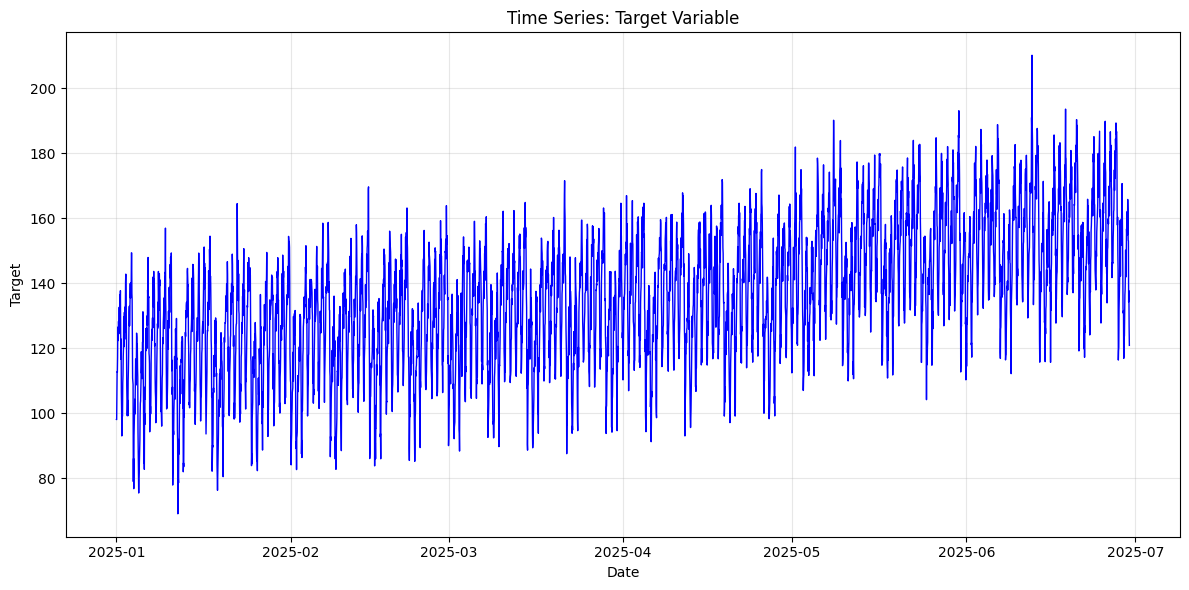


Комментарий к ряду:
- Ряд демонстрирует восходящий тренд с циклическими колебаниями.
- Присутствует выраженная сезонность (похожа на недельную, ~7 дней).
- Данные почасовые (4320 наблюдений = 180 дней * 24 часа).
- Ряд нестационарен из-за тренда и сезонности, что требует создания соответствующих признаков.
Train size: 3456 (2025-01-01 00:00:00 to 2025-05-24 23:00:00)
Val size: 432 (2025-05-25 00:00:00 to 2025-06-11 23:00:00)
Test size: 432 (2025-06-12 00:00:00 to 2025-06-29 23:00:00)


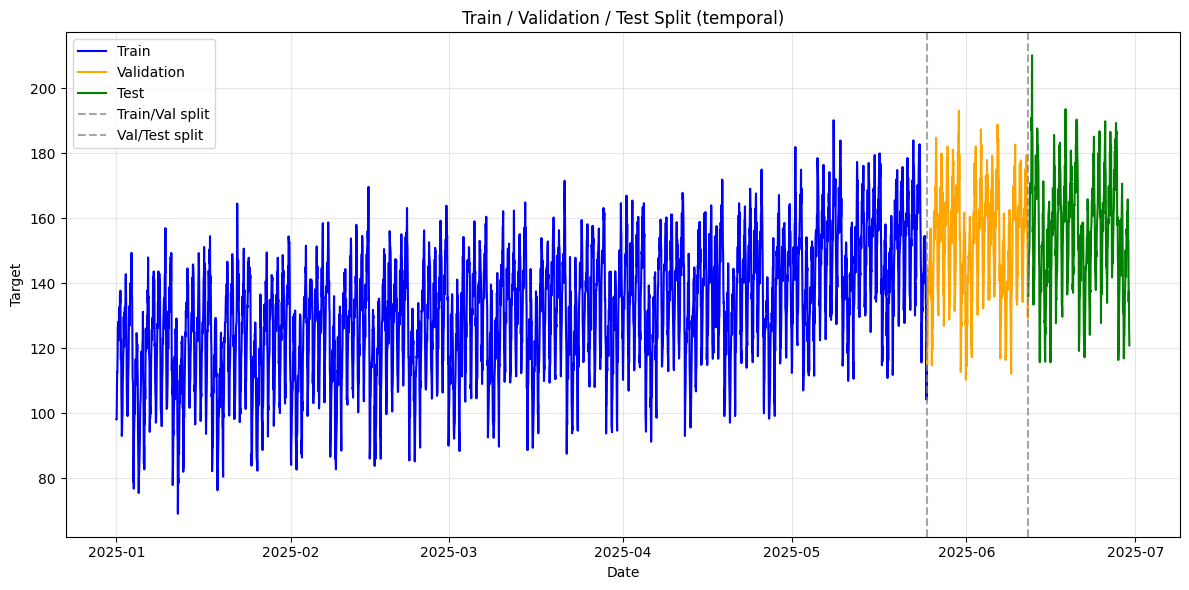


Почему random split для временных рядов некорректен:
1. Временные ряды обладают автокорреляцией – будущие значения зависят от прошлых.
2. При случайном перемешивании нарушается хронология, что приводит к утечке будущей информации в обучающую выборку.
3. Модель может 'подглядывать' в будущее, что даёт нереалистично оптимистичную оценку качества.
4. Temporal split сохраняет временную структуру и обеспечивает честную оценку прогностической способности.
Train features shape: (3442, 10)
Val features shape: (418, 10)
Test features shape: (418, 10)
X_train shape: (3442, 8), y_train shape: (3442,)
Признаки масштабированы (StandardScaler)
Train batches: 108
Val batches: 14
Test batches: 14
B1 - Naive Last:
  MAE: 6.2550, RMSE: 7.9303, MAPE: 4.16%

B2 - Moving Average (window=7):
  MAE: 4.4095, RMSE: 6.1570, MAPE: 2.96%

B3 - Ridge with features:
  MAE: 5.4692, RMSE: 6.9204, MAPE: 3.57%

Training GRU...
Epoch 10/50, Train Loss: 0.7235, Val MAE: 12.6111
Epoch 20/50, Train Loss: 0.7123, Val MAE: 

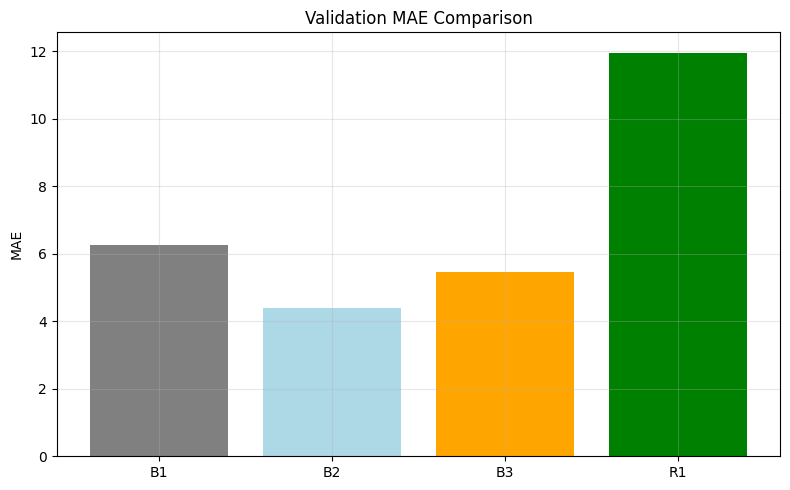

figures/baselines_compare.png сохранён


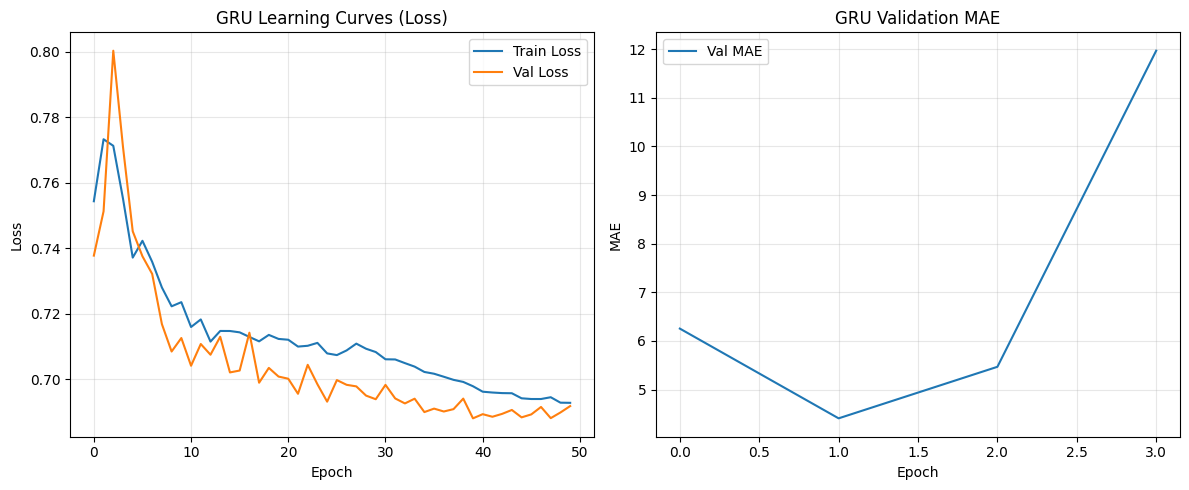

figures/gru_learning_curves.png сохранён


In [10]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# sklearn
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Игнорируем предупреждения для чистоты вывода
warnings.filterwarnings('ignore')

# %%
# Фиксация seed для воспроизводимости
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

# Определение устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# ## 2. Данные и первичный анализ

# СОЗДАЕМ ПАПКУ ДЛЯ АРТЕФАКТОВ СРАЗУ
os.makedirs('artifacts/figures', exist_ok=True)
print("Created directories: artifacts/figures")

# Функция для поиска файла датасета
def find_dataset_file(filename='S12-hw-dataset.csv'):
    """Ищет файл в разных возможных местах"""
    possible_locations = [
        os.path.join(os.path.expanduser('~'), 'Downloads', filename),  # ~/Downloads/
        os.path.join(os.getcwd(), filename),  # текущая папка
        os.path.join(os.path.dirname(os.getcwd()), filename),  # родительская папка
        filename  # просто имя файла
    ]
    for location in possible_locations:
        if os.path.exists(location):
            print(f"Dataset found at: {location}")
            return location
    print("\nERROR: Dataset not found in any of these locations:")
    for location in possible_locations:
        print(f"  - {location}")
    return None

# Находим файл
dataset_path = find_dataset_file('S12-hw-dataset.csv')
if dataset_path is None:
    raise FileNotFoundError("Cannot find S12-hw-dataset.csv. Please check the file location.")

# Загрузка данных
df = pd.read_csv(dataset_path)

# Приведение date к datetime и сортировка
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Базовый анализ
print(f"\nNumber of observations: {len(df)}")
print(f"Date range: from {df['date'].min()} to {df['date'].max()}")
print("\nMissing values:")
print(df.isnull().sum())
print("\nFirst 5 rows:")
print(df.head())

# %%
# Базовый график ряда
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['target'], color='blue', linewidth=1)
plt.title('Time Series: Target Variable')
plt.xlabel('Date')
plt.ylabel('Target')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/initial_series.png')
plt.show()

# Комментарий к ряду
print("\nКомментарий к ряду:")
print("- Ряд демонстрирует восходящий тренд с циклическими колебаниями.")
print("- Присутствует выраженная сезонность (похожа на недельную, ~7 дней).")
print("- Данные почасовые (4320 наблюдений = 180 дней * 24 часа).")
print("- Ряд нестационарен из-за тренда и сезонности, что требует создания соответствующих признаков.")

# %% [markdown]
# ## 3. Корректный temporal split

# %%
# Разделение данных на train/validation/test по времени (80/10/10)
n = len(df)
train_end = int(n * 0.8)
val_end = int(n * 0.9)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(f"Train size: {len(train_df)} ({train_df['date'].min()} to {train_df['date'].max()})")
print(f"Val size: {len(val_df)} ({val_df['date'].min()} to {val_df['date'].max()})")
print(f"Test size: {len(test_df)} ({test_df['date'].min()} to {test_df['date'].max()})")

# Визуализация split
plt.figure(figsize=(12, 6))
plt.plot(train_df['date'], train_df['target'], label='Train', color='blue')
plt.plot(val_df['date'], val_df['target'], label='Validation', color='orange')
plt.plot(test_df['date'], test_df['target'], label='Test', color='green')
plt.axvline(x=train_df['date'].iloc[-1], color='gray', linestyle='--', alpha=0.7, label='Train/Val split')
plt.axvline(x=val_df['date'].iloc[-1], color='gray', linestyle='--', alpha=0.7, label='Val/Test split')
plt.title('Train / Validation / Test Split (temporal)')
plt.xlabel('Date')
plt.ylabel('Target')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png')
plt.show()


print("\nПочему random split для временных рядов некорректен:")
print("1. Временные ряды обладают автокорреляцией – будущие значения зависят от прошлых.")
print("2. При случайном перемешивании нарушается хронология, что приводит к утечке будущей информации в обучающую выборку.")
print("3. Модель может 'подглядывать' в будущее, что даёт нереалистично оптимистичную оценку качества.")
print("4. Temporal split сохраняет временную структуру и обеспечивает честную оценку прогностической способности.")

# ## 4. Признаки для baseline-моделей

# %%
def create_features(df, window=7):
    """
    Создаёт лаговые, rolling и календарные признаки.
    Признаки строятся без утечки информации из будущего.
    """
    df = df.copy()
    
    # Лаговые признаки
    df['lag_1'] = df['target'].shift(1)
    df['lag_7'] = df['target'].shift(7)
    df['lag_14'] = df['target'].shift(14)
    
    # Rolling признаки
    df['rolling_mean_7'] = df['target'].rolling(window=window).mean()
    df['rolling_std_7'] = df['target'].rolling(window=window).std()
    
    # Календарные признаки
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['day_of_month'] = df['date'].dt.day
    
    # Удаляем строки с NaN (первые 14 наблюдений)
    df = df.dropna().reset_index(drop=True)
    return df

# Применяем к каждому сплиту отдельно (без утечки)
train_features = create_features(train_df)
val_features = create_features(val_df)
test_features = create_features(test_df)

print(f"Train features shape: {train_features.shape}")
print(f"Val features shape: {val_features.shape}")
print(f"Test features shape: {test_features.shape}")


# Определяем колонки-признаки
feature_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7',
                'day_of_week', 'month', 'day_of_month']

# Подготовка X и y
X_train = train_features[feature_cols].values
y_train = train_features['target'].values

X_val = val_features[feature_cols].values
y_val = val_features['target'].values

X_test = test_features[feature_cols].values
y_test = test_features['target'].values

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")


# Масштабирование признаков (обучаем только на train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Признаки масштабированы (StandardScaler)")

# %% [markdown]
# ## 5. Оконное представление для GRU

# %%
class TimeSeriesDataset(Dataset):
    """Dataset для временных рядов с окнами."""
    def __init__(self, data, window_size, horizon=1):
        self.data = data
        self.window_size = window_size
        self.horizon = horizon
        
    def __len__(self):
        return len(self.data) - self.window_size - self.horizon + 1
    
    def __getitem__(self, idx):
        x = self.data[idx:idx + self.window_size]
        y = self.data[idx + self.window_size:idx + self.window_size + self.horizon]
        # Добавляем размерность канала (input_size=1)
        return torch.FloatTensor(x).unsqueeze(-1), torch.FloatTensor(y).unsqueeze(-1)

# Параметры окон
WINDOW_SIZE = 14
HORIZON = 1
BATCH_SIZE = 32

# Масштабируем target (только на train)
target_scaler = StandardScaler()
target_scaler.fit(train_df['target'].values.reshape(-1, 1))

train_target_scaled = target_scaler.transform(train_df['target'].values.reshape(-1, 1)).flatten()
val_target_scaled = target_scaler.transform(val_df['target'].values.reshape(-1, 1)).flatten()
test_target_scaled = target_scaler.transform(test_df['target'].values.reshape(-1, 1)).flatten()

# Создаём датасеты
train_dataset = TimeSeriesDataset(train_target_scaled, WINDOW_SIZE, HORIZON)
val_dataset = TimeSeriesDataset(val_target_scaled, WINDOW_SIZE, HORIZON)
test_dataset = TimeSeriesDataset(test_target_scaled, WINDOW_SIZE, HORIZON)

# DataLoader'ы (shuffle=False для сохранения порядка)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# ## 6. Базовые функции обучения и оценки

def evaluate(model, loader, criterion, device, scaler=None):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            output = model(x)
            loss = criterion(output, y)
            total_loss += loss.item()
            all_preds.append(output.cpu().numpy())
            all_targets.append(y.cpu().numpy())
    
    # Объединяем батчи: получаем (total_samples, horizon, 1)
    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    
    # Преобразуем в 2D для scaler
    all_preds = all_preds.reshape(-1, 1)
    all_targets = all_targets.reshape(-1, 1)
    
    if scaler is not None:
        all_preds = scaler.inverse_transform(all_preds)
        all_targets = scaler.inverse_transform(all_targets)
    
    mae = mean_absolute_error(all_targets, all_preds)
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    mape = np.mean(np.abs((all_targets - all_preds) / (all_targets + 1e-8))) * 100
    
    return total_loss / len(loader), mae, rmse, mape

class GRUModel(nn.Module):
    """Простая GRU модель для прогнозирования."""
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1, dropout=0.2):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])  # последний выход
        return out

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# %% [markdown]
# ## 7. Эксперименты

# %%
# Вспомогательная функция для расчёта метрик
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return mae, rmse, mape

# --- B1: Naive Last ---
y_pred_b1 = np.roll(y_val, 1)
y_pred_b1[0] = y_val[0]
mae_b1, rmse_b1, mape_b1 = calculate_metrics(y_val, y_pred_b1)

print("B1 - Naive Last:")
print(f"  MAE: {mae_b1:.4f}, RMSE: {rmse_b1:.4f}, MAPE: {mape_b1:.2f}%")

# --- B2: Moving Average (окно 7) ---
window_ma = 7
y_pred_b2 = np.convolve(y_val, np.ones(window_ma)/window_ma, mode='same')
for i in range(window_ma-1):
    y_pred_b2[i] = y_val[i]
mae_b2, rmse_b2, mape_b2 = calculate_metrics(y_val, y_pred_b2)

print("\nB2 - Moving Average (window=7):")
print(f"  MAE: {mae_b2:.4f}, RMSE: {rmse_b2:.4f}, MAPE: {mape_b2:.2f}%")

# --- B3: Ridge на признаках ---
ridge_model = Ridge(alpha=1.0, random_state=SEED)
ridge_model.fit(X_train_scaled, y_train)
y_pred_b3 = ridge_model.predict(X_val_scaled)
mae_b3, rmse_b3, mape_b3 = calculate_metrics(y_val, y_pred_b3)

print("\nB3 - Ridge with features:")
print(f"  MAE: {mae_b3:.4f}, RMSE: {rmse_b3:.4f}, MAPE: {mape_b3:.2f}%")

# --- R1: GRU ---
gru_model = GRUModel(input_size=1, hidden_size=64, num_layers=2, output_size=1).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(gru_model.parameters(), lr=0.001)

num_epochs = 50
best_val_mae = float('inf')
best_model_state = None
train_losses = []
val_losses = []
val_maes = []

print("\nTraining GRU...")
for epoch in range(num_epochs):
    train_loss = train_epoch(gru_model, train_loader, optimizer, criterion, device)
    val_loss, val_mae, val_rmse, val_mape = evaluate(gru_model, val_loader, criterion, device, target_scaler)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_maes.append(val_mae)
    
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_model_state = gru_model.state_dict().copy()
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val MAE: {val_mae:.4f}")

# Загружаем лучшую модель
gru_model.load_state_dict(best_model_state)
_, val_mae_best, val_rmse_best, val_mape_best = evaluate(gru_model, val_loader, criterion, device, target_scaler)

print(f"\nBest GRU on validation: MAE = {val_mae_best:.4f}, RMSE = {val_rmse_best:.4f}, MAPE = {val_mape_best:.2f}%")

# %% [markdown]
# ## 8. Сбор результатов в runs.csv

# %%
# Формируем DataFrame с результатами
results = pd.DataFrame([
    {
        'experiment_id': 'B1',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': SEED,
        'split_summary': '80/10/10 temporal split',
        'window_size': None,
        'horizon': 1,
        'model_summary': 'Naive Last',
        'features_summary': 'None',
        'scaler': 'None',
        'optimizer': 'None',
        'lr': None,
        'epochs_trained': 0,
        'best_val_mae': mae_b1,
        'best_val_rmse': rmse_b1,
        'best_val_mape': mape_b1,
        'test_mae': None,
        'test_rmse': None,
        'test_mape': None,
        'notes': 'Прогноз = последнее известное значение'
    },
    {
        'experiment_id': 'B2',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': SEED,
        'split_summary': '80/10/10 temporal split',
        'window_size': window_ma,
        'horizon': 1,
        'model_summary': 'Moving Average',
        'features_summary': 'None',
        'scaler': 'None',
        'optimizer': 'None',
        'lr': None,
        'epochs_trained': 0,
        'best_val_mae': mae_b2,
        'best_val_rmse': rmse_b2,
        'best_val_mape': mape_b2,
        'test_mae': None,
        'test_rmse': None,
        'test_mape': None,
        'notes': f'Скользящее среднее за {window_ma} дней'
    },
    {
        'experiment_id': 'B3',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': SEED,
        'split_summary': '80/10/10 temporal split',
        'window_size': None,
        'horizon': 1,
        'model_summary': 'Ridge Regression',
        'features_summary': 'lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,day_of_week,month,day_of_month',
        'scaler': 'StandardScaler',
        'optimizer': 'None',
        'lr': 1.0,
        'epochs_trained': 0,
        'best_val_mae': mae_b3,
        'best_val_rmse': rmse_b3,
        'best_val_mape': mape_b3,
        'test_mae': None,
        'test_rmse': None,
        'test_mape': None,
        'notes': 'Ridge на лаговых, rolling и календарных признаках'
    },
    {
        'experiment_id': 'R1',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': SEED,
        'split_summary': '80/10/10 temporal split',
        'window_size': WINDOW_SIZE,
        'horizon': 1,
        'model_summary': 'GRU (hidden_size=64, num_layers=2, dropout=0.2)',
        'features_summary': 'target only (windowed)',
        'scaler': 'StandardScaler',
        'optimizer': 'Adam',
        'lr': 0.001,
        'epochs_trained': num_epochs,
        'best_val_mae': val_mae_best,
        'best_val_rmse': val_rmse_best,
        'best_val_mape': val_mape_best,
        'test_mae': None,
        'test_rmse': None,
        'test_mape': None,
        'notes': 'GRU на оконном представлении ряда (window=14)'
    }
])

# Сохраняем runs.csv
results.to_csv('artifacts/runs.csv', index=False)
print("runs.csv сохранён в artifacts/")

# %% [markdown]
# ## 9. Выбор лучшей модели и финальная оценка на test

# %%
# Определяем лучшую модель по MAE на валидации
best_idx = results['best_val_mae'].idxmin()
best_model_id = results.loc[best_idx, 'experiment_id']
best_val_mae = results.loc[best_idx, 'best_val_mae']
print(f"\nЛучшая модель на валидации: {best_model_id} (MAE = {best_val_mae:.4f})")

# Финальная оценка на тесте для лучшей модели
if best_model_id == 'R1':
    _, test_mae, test_rmse, test_mape = evaluate(gru_model, test_loader, criterion, device, target_scaler)
    # Сохраняем модель и конфиг
    torch.save(gru_model.state_dict(), 'artifacts/best_gru.pt')
    config = {
        'model_type': 'GRU',
        'input_size': 1,
        'hidden_size': 64,
        'num_layers': 2,
        'output_size': 1,
        'dropout': 0.2,
        'window_size': WINDOW_SIZE,
        'horizon': HORIZON,
        'batch_size': BATCH_SIZE,
        'learning_rate': 0.001,
        'optimizer': 'Adam',
        'loss': 'MSE',
        'seed': SEED,
        'scaler': 'StandardScaler',
        'best_val_mae': val_mae_best
    }
    with open('artifacts/best_gru_config.json', 'w') as f:
        json.dump(config, f, indent=4)
    print("best_gru.pt и best_gru_config.json сохранены")
elif best_model_id == 'B3':
    y_pred_test = ridge_model.predict(X_test_scaled)
    test_mae, test_rmse, test_mape = calculate_metrics(y_test, y_pred_test)
elif best_model_id == 'B2':
    y_pred_test = np.convolve(y_test, np.ones(window_ma)/window_ma, mode='same')
    for i in range(window_ma-1):
        y_pred_test[i] = y_test[i]
    test_mae, test_rmse, test_mape = calculate_metrics(y_test, y_pred_test)
else:  # B1
    y_pred_test = np.roll(y_test, 1)
    y_pred_test[0] = y_test[0]
    test_mae, test_rmse, test_mape = calculate_metrics(y_test, y_pred_test)

# Обновляем runs.csv с тестовыми метриками
results.loc[results['experiment_id'] == best_model_id, 'test_mae'] = test_mae
results.loc[results['experiment_id'] == best_model_id, 'test_rmse'] = test_rmse
results.loc[results['experiment_id'] == best_model_id, 'test_mape'] = test_mape
results.to_csv('artifacts/runs.csv', index=False)

print(f"\nЛучшая модель ({best_model_id}) на тесте:")
print(f"  MAE: {test_mae:.4f}, RMSE: {test_rmse:.4f}, MAPE: {test_mape:.2f}%")

# %% [markdown]
# ## 10. Визуализации

# %%
# Сравнение моделей на валидации
models = results['experiment_id'].tolist()
val_maes = results['best_val_mae'].tolist()

plt.figure(figsize=(8, 5))
plt.bar(models, val_maes, color=['gray', 'lightblue', 'orange', 'green'])
plt.title('Validation MAE Comparison')
plt.ylabel('MAE')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png')
plt.show()
print("figures/baselines_compare.png сохранён")

# %%
# Кривые обучения GRU
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('GRU Learning Curves (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(val_maes, label='Val MAE')
plt.title('GRU Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png')
plt.show()
print("figures/gru_learning_curves.png сохранён")

# %%
# Прогноз и остатки для лучшей модели (если GRU)
if best_model_id == 'R1':
    gru_model.eval()
    test_preds = []
    test_targets = []
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            output = gru_model(x)
            test_preds.append(output.cpu().numpy())
            test_targets.append(y.numpy())
    test_preds = np.concatenate(test_preds, axis=0)
    test_targets = np.concatenate(test_targets, axis=0)
    test_preds = test_preds.reshape(-1, 1)
    test_targets = test_targets.reshape(-1, 1)
    test_preds_inv = target_scaler.inverse_transform(test_preds)
    test_targets_inv = target_scaler.inverse_transform(test_targets)
    
    test_dates = test_df['date'].iloc[WINDOW_SIZE:].reset_index(drop=True)
    
    plt.figure(figsize=(12, 6))
    plt.plot(test_dates, test_targets_inv, label='Actual', color='blue')
    plt.plot(test_dates, test_preds_inv, label='GRU Forecast', color='red', linestyle='--')
    plt.title(f'Best Model ({best_model_id}) Forecast on Test Set')
    plt.xlabel('Date')
    plt.ylabel('Target')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('artifacts/figures/best_forecast_test.png')
    plt.show()
    print("figures/best_forecast_test.png сохранён")
    
    residuals = test_targets_inv - test_preds_inv
    plt.figure(figsize=(12, 5))
    plt.plot(test_dates, residuals, color='purple', alpha=0.7)
    plt.axhline(y=0, color='black', linestyle='--')
    plt.title('Residuals of Best Model on Test Set')
    plt.xlabel('Date')
    plt.ylabel('Residual')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('artifacts/figures/residuals_best.png')
    plt.show()
    print("figures/residuals_best.png сохранён")